In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

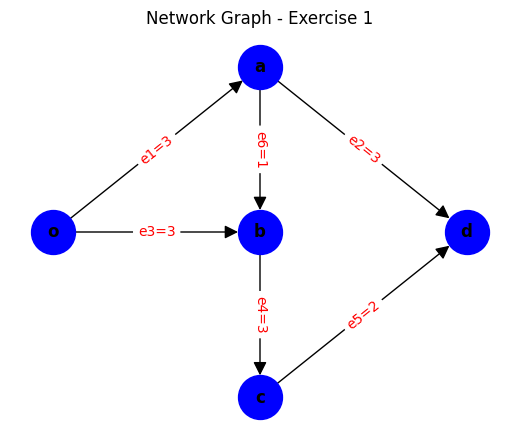

In [2]:
G = nx.DiGraph()
G.add_edge('o', 'a', capacity=3, label='e1=3')
G.add_edge('o', 'b', capacity=3, label='e3=3')
G.add_edge('a', 'd', capacity=3, label='e2=3')
G.add_edge('b', 'c', capacity=3, label='e4=3')
G.add_edge('c', 'd', capacity=2, label='e5=2')
G.add_edge('a', 'b', capacity=1, label='e6=1')

pos = {
    'o': (0, 1),
    'a': (1, 2),
    'b': (1, 1),
    'c': (1, 0),
    'd': (2, 1)
}

edge_labels = {(u, v): data['label'] for u, v, data in G.edges(data=True)}

plt.figure(figsize=(5, 4))
nx.draw(G, pos, with_labels=True, node_color='blue', node_size=1000,
        arrows=True, arrowsize=20, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Network Graph - Exercise 1")
plt.axis('off')
plt.show()


ex1

a

In [3]:
def find_min_cut(G, S='o', T='d'):
    # compute minimum s-t cut using edge capacities
    cut_val, parts = nx.minimum_cut(G, S, T, capacity='capacity')
    
    # split nodes into source-side and target-side
    s_part, t_part = parts
    
    # print results in a clean way
    print(f"Minimum cut value = {cut_val}")
    print(f"S-side nodes: {sorted(s_part)}")
    print(f"T-side nodes: {sorted(t_part)}")

# run the function
find_min_cut(G)


Minimum cut value = 5
S-side nodes: ['a', 'b', 'c', 'o']
T-side nodes: ['d']


b

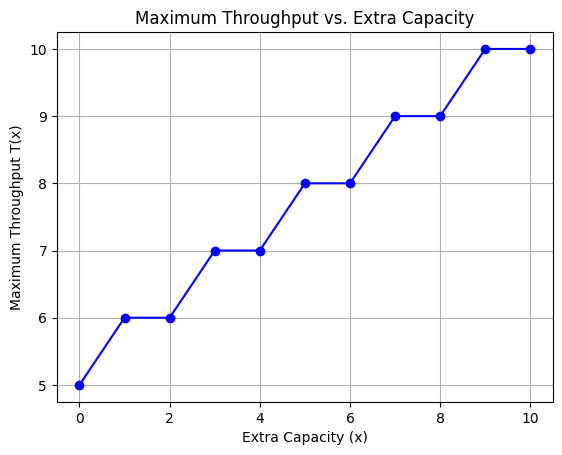

In [4]:
%matplotlib inline

# simple throughput function that grows step-by-step
def max_throughput(x):
    return 5 + np.floor((x + 1) / 2)

# x range from 0 to 10
x_values = np.arange(0, 11)

# compute throughput for each x
throughput_values = [max_throughput(x) for x in x_values]

# plot the curve
plt.plot(x_values, throughput_values, marker='o', color='blue')
plt.xlabel("Extra Capacity (x)")
plt.ylabel("Maximum Throughput T(x)")
plt.title("Maximum Throughput vs. Extra Capacity")
plt.grid(True)
plt.show()


c

x  T(x) with e8=o->d      T(x) with e8=b->d
 0          6                  6
 1          7                  6
 2          8                  7
 3          9                  7
 4         10                  8
 5         11                  8
 6         12                  9
 7         13                  9
 8         14                 10
 9         15                 10
10         16                 11
11         17                 11
12         18                 12


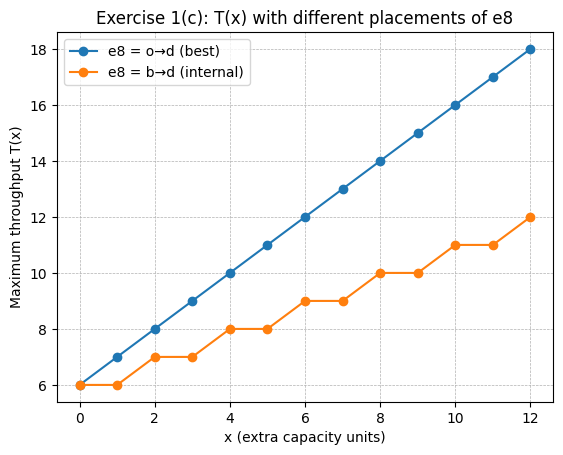

In [5]:
import itertools

# fixed order of edges so we can index capacities and added units
edge_order = [('o','a'), ('o','b'), ('a','d'), ('b','c'), ('c','d'), ('a','b')]
base_caps = [G[u][v]['capacity'] for (u,v) in edge_order]

def best_T_series_with_e8(e8_u, e8_v, X_MAX=10):
    # for each extra capacity x, we search for the best way to distribute it
    series = []
    for x in range(0, X_MAX+1):
        best_val = -1

        # all ways to distribute x units (with repetition) over 7 "slots" (6 edges + e8)
        for picks in itertools.combinations_with_replacement(range(7), x):
            adds = [0]*7
            for idx in picks:
                adds[idx] += 1

            # build a new graph H with updated capacities
            H = nx.DiGraph()
            H.add_nodes_from(G.nodes())

            # first 6 base edges with extra capacity
            for i,(u,v) in enumerate(edge_order):
                H.add_edge(u, v, capacity=base_caps[i] + adds[i])

            # extra edge e8 with base capacity 1 plus added units
            H.add_edge(e8_u, e8_v, capacity=1 + adds[6])

            # compute max flow for this allocation
            val, _ = nx.maximum_flow(H, 'o', 'd', capacity='capacity')
            if val > best_val:
                best_val = val

        series.append(best_val)
    return series

X_MAX = 12
# best throughput series when we place e8 directly from o to d
series_od = best_T_series_with_e8('o','d', X_MAX=X_MAX)
# best throughput series when we place e8 from b to d
series_bd = best_T_series_with_e8('b','d', X_MAX=X_MAX)

print("x  T(x) with e8=o->d      T(x) with e8=b->d")
for x in range(0, X_MAX+1):
    print(f"{x:2d} {series_od[x]:>10} {series_bd[x]:>18}")

# plot both strategies on the same figure for comparison
xs = list(range(0, X_MAX+1))
plt.figure()
plt.plot(xs, series_od, marker='o', label='e8 = o→d (best)')
plt.plot(xs, series_bd, marker='o', label='e8 = b→d (internal)')
plt.xlabel('x (extra capacity units)')
plt.ylabel('Maximum throughput T(x)')
plt.title('Exercise 1(c): T(x) with different placements of e8')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


ex2

a

In [6]:
import numpy as np
import networkx as nx

# --- build the graph exactly like Figure 2 ---
G = nx.Graph()

# fully connect nodes n1..n5 (this creates the clique on top)
for i in range(1, 6):
    for j in range(i + 1, 6):
        G.add_edge(f"n{i}", f"n{j}")

# connect n6 to the clique (n1..n5), plus n7 and n15
for i in range(1, 6):
    G.add_edge("n6", f"n{i}")
G.add_edges_from([("n6", "n7"), ("n6", "n15")])

# small chain n7–n8–n9 in the middle
G.add_edges_from([("n7", "n8"), ("n8", "n9")])

# star centered at n9 with leaves n10..n14
for i in range(10, 15):
    G.add_edge("n9", f"n{i}")

# --- compute Katz centrality using the official formula ---
beta = 0.15
n = len(G.nodes())

# adjacency matrix with a fixed node order
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
I = np.eye(n)

# vector of ones (this is the "baseline" influence for every node)
mu = np.ones((n, 1))

# solve (I - βA)x = μ  → Katz centrality vector x
x = np.linalg.solve(I - beta * A, mu)

# normalize so the largest centrality becomes 1 (just for easier comparison)
x = x / np.max(x)

# pack results into a dictionary: node → centrality value
nodes = sorted(G.nodes())
katz = dict(zip(nodes, x.flatten()))

print("Katz centrality (β = 0.15):")
for node, val in katz.items():
    print(f"{node}: {val:.4f}")

# highlight the two nodes we care about in the homework
print("\nFocus nodes:")
print("n6 =", round(katz['n6'], 4))
print("n9 =", round(katz['n9'], 4))


Katz centrality (β = 0.15):
n1: 0.8994
n10: 0.2805
n11: 0.2805
n12: 0.2805
n13: 0.2805
n14: 0.2805
n15: 0.3598
n2: 0.8994
n3: 0.8994
n4: 0.8994
n5: 0.8994
n6: 1.0000
n7: 0.4111
n8: 0.3422
n9: 0.4715

Focus nodes:
n6 = 1.0
n9 = 0.4715


b

In [7]:
import networkx as nx

beta = 0.15                         # teleport probability
nodes = sorted(G.nodes())           # fixed node order
idx = {v: i for i, v in enumerate(nodes)}
n = len(nodes)

# build column-stochastic transition matrix P
# P[j, i] = 1/deg(i) if there is an edge i -> j  (for undirected, neighbors)
P = np.zeros((n, n), float)
deg = np.array([G.degree(v) for v in nodes], dtype=float)

for i, u in enumerate(nodes):
    if deg[i] == 0:
        # handle dangling nodes (not expected here, but kept for completeness)
        P[:, i] = 1.0 / n
    else:
        # spread probability equally over all neighbors of u
        for v in G.neighbors(u):
            j = idx[v]
            P[j, i] = 1.0 / deg[i]

# PageRank update: x = beta * μ + (1 - beta) * P @ x
mu = np.ones(n) / n                 # uniform teleport distribution
x = np.ones(n) / n                  # start from uniform vector

tol, it_max = 1e-12, 10_000         # stopping tolerance and max iterations

for _ in range(it_max):
    x_new = beta * mu + (1 - beta) * (P @ x)
    # stop when the L1 difference is very small
    if np.linalg.norm(x_new - x, 1) < tol:
        x = x_new
        break
    x = x_new

# pack results into a dict: node → PageRank score
pr = {nodes[i]: float(x[i]) for i in range(n)}

# print nodes sorted from highest to lowest PageRank
for k, v in sorted(pr.items(), key=lambda t: t[1], reverse=True):
    print(f"{k:>3s}: {v:.6f}")

# highlight the two focus nodes for the exercise
print("\nFocus:")
print("n6 =", round(pr["n6"], 6))
print("n9 =", round(pr["n9"], 6))


 n9: 0.194044
 n6: 0.114450
 n1: 0.074680
 n2: 0.074680
 n3: 0.074680
 n4: 0.074680
 n5: 0.074680
 n8: 0.058149
 n7: 0.048611
n10: 0.037490
n11: 0.037490
n12: 0.037490
n13: 0.037490
n14: 0.037490
n15: 0.023898

Focus:
n6 = 0.11445
n9 = 0.194044


d

In [8]:
def pagerank_iter(G, beta=0.15, tol=1e-12, it_max=10000):
    nodes = sorted(G.nodes())
    n = len(nodes)
    idx = {v: i for i, v in enumerate(nodes)}

    # build column-stochastic transition matrix P
    P = np.zeros((n, n), float)
    deg = np.array([G.degree(v) for v in nodes], float)

    for i, u in enumerate(nodes):
        if deg[i] == 0:
            # spread uniform mass for dangling nodes (not expected here)
            P[:, i] = 1.0 / n
        else:
            # random walk transition: equal probability to each neighbor
            for v in G.neighbors(u):
                P[idx[v], i] = 1.0 / deg[i]

    # uniform teleport distribution
    mu = np.ones(n) / n
    # start with uniform PageRank vector
    x = np.ones(n) / n

    # iterative PageRank update
    for _ in range(it_max):
        x_new = beta * mu + (1 - beta) * (P @ x)
        # stop if change is very small (L1 norm)
        if np.linalg.norm(x_new - x, 1) < tol:
            x = x_new
            break
        x = x_new

    # convert vector to dictionary
    return {nodes[i]: float(x[i]) for i in range(n)}

# run PageRank for several beta values
betas = [0, 0.25, 0.5, 0.75, 1.0]
rows = []
for b in betas:
    pr = pagerank_iter(G, beta=b)
    rows.append((b, pr['n6'], pr['n9'], pr['n6'] - pr['n9']))

# print in a clean table
print("beta   PR(n6)       PR(n9)       diff = PR(n6)-PR(n9)")
for b, p6, p9, d in rows:
    print(f"{b:>4}   {p6: .6f}   {p9: .6f}   {d: .6f}")


beta   PR(n6)       PR(n9)       diff = PR(n6)-PR(n9)
   0    0.145833    0.125000    0.020833
0.25    0.110604    0.191116   -0.080511
 0.5    0.101404    0.166693   -0.065289
0.75    0.087507    0.126978   -0.039471
 1.0    0.066667    0.066667    0.000000


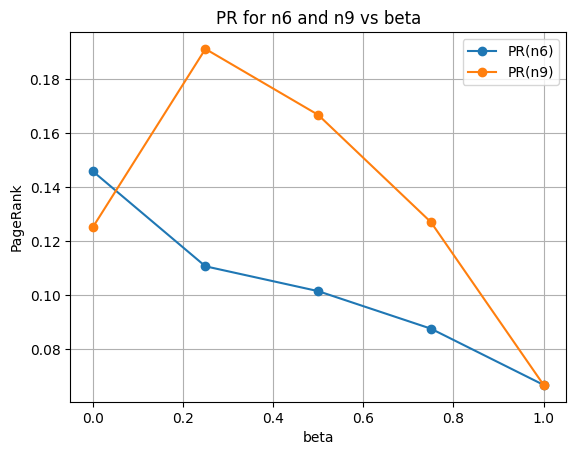

In [9]:
import matplotlib.pyplot as plt
xs = [r[0] for r in rows]
p6 = [r[1] for r in rows]
p9 = [r[2] for r in rows]
plt.plot(xs, p6, marker='o', label='PR(n6)')
plt.plot(xs, p9, marker='o', label='PR(n9)')
plt.xlabel('beta'); plt.ylabel('PageRank'); plt.title('PR for n6 and n9 vs beta'); plt.grid(True); plt.legend(); plt.show()



We compute PageRank with uniform μ for β ∈ {0, 1/4, 1/2, 3/4, 1}.
The difference
Δ(β)=PR(n6)−PR(n9) is **not monotone** in β. At **β = 0** (pure link-following), PR equals the random-walk stationary distribution on this undirected graph, i.e., it is proportional to degree; since (deg(n_6)=7) and (deg(n_9)=6), we get **PR(n6) > PR(n9)** ⇒ (Δ(0) > 0).
At **β = 1** (pure teleportation), PageRank becomes uniform over nodes, so **PR(n6) = PR(n9)** ⇒ (Δ(1)=0).
For **intermediate β**, (n_9) typically **overtakes** (n_6) because the five degree-1 leaves (n10–n14) pass their entire rank to n9 (undiluted), whereas n6 receives diluted rank from high-degree neighbors in the K5 clique.
Hence (Δ(β)) crosses zero: positive at β=0, negative for a range of intermediate β, and returning to 0 at β=1.


exercise 3 

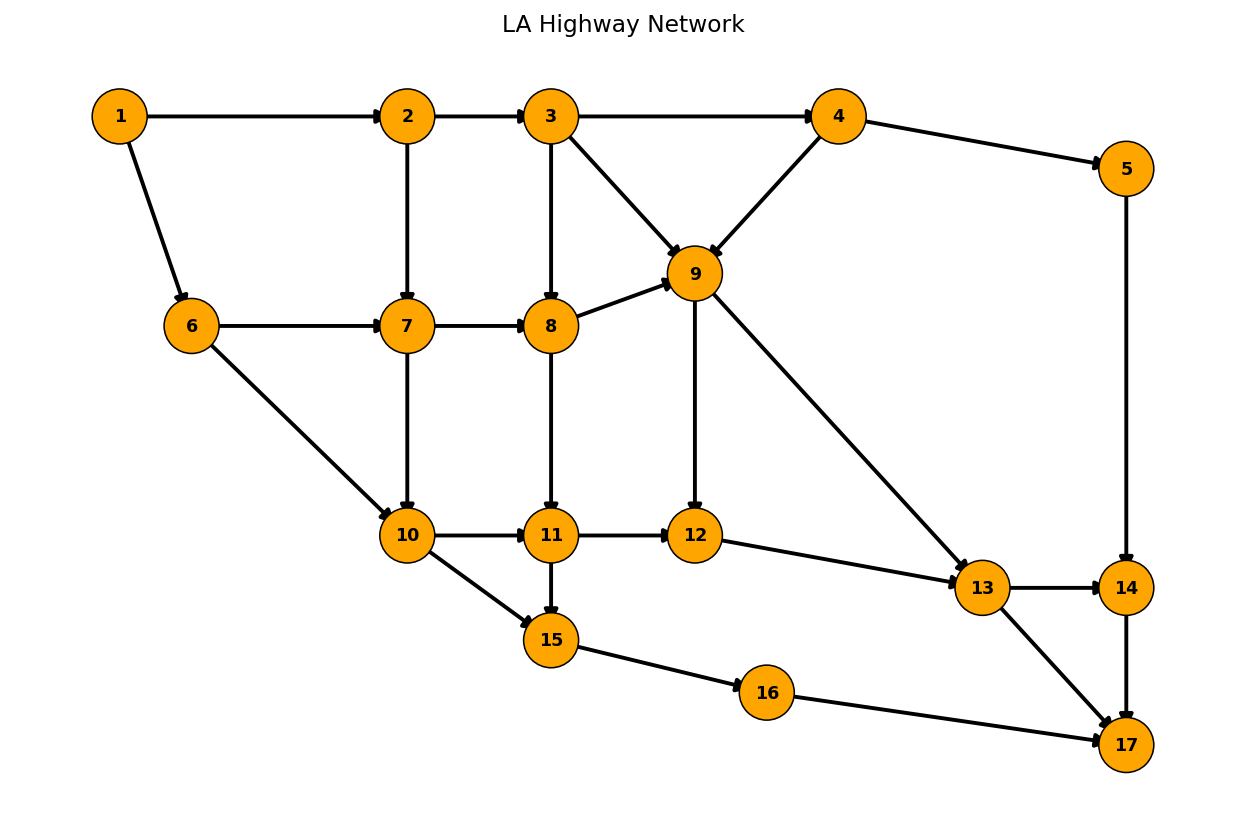

In [10]:
import numpy as np
import scipy.io
import networkx as nx
import matplotlib.pyplot as plt

# Load .mat files exactly as given in the assignment

B = scipy.io.loadmat('traffic.mat')['traffic']                    # incidence matrix (17 x 28)
C = scipy.io.loadmat('capacities.mat')['capacities'].reshape(-1)  # capacities for each link (28,)
L = scipy.io.loadmat('traveltime.mat')['traveltime'].reshape(-1)  # free-flow travel times (28,)
F = scipy.io.loadmat('flow.mat')['flow'].reshape(-1)              # reference flows (28,)

# Build a directed graph from the incidence matrix we detect tail (+1) and head (-1) without using argmax/argmin

n_nodes, n_links = B.shape
G = nx.DiGraph()
G.add_nodes_from(range(1, n_nodes + 1))  # nodes are 1..17 like in the slides

for e in range(n_links):
    # find which row has +1 → tail node
    tail_idx = int(np.flatnonzero(B[:, e] ==  1)[0]) + 1  # convert to 1-based id
    # find which row has -1 → head node
    head_idx = int(np.flatnonzero(B[:, e] == -1)[0]) + 1

    # create directed edge and attach the data we need later
    G.add_edge(
        tail_idx,
        head_idx,
        eid=e + 1,                 # link index (1..28)
        capacity=float(C[e]),      # link capacity
        weight=float(L[e]),        # travel time (used as weight)
        flow=float(F[e])           # given flow on that link
    )

# Fixed positions to mimic the layout of the reference figure

pos = {
    1:(0,12),  2:(4,12),  3:(6,12),  4:(10,12), 5:(14,11),
    6:(1,8),   7:(4,8),   8:(6,8),   9:(8,9),
    10:(4,4), 11:(6,4),  12:(8,4),
    13:(12,3), 14:(14,3),
    15:(6,2), 16:(9,1),  17:(14,0)
}

# Plot a clean, readable version of the network

plt.figure(dpi=140, figsize=(9, 6))

# all nodes in the same color, just to make the network easy to read
node_colors = ['orange'] * G.number_of_nodes()

nx.draw_networkx_nodes(
    G, pos,
    node_size=800,
    node_color=node_colors,
    edgecolors='k',
    linewidths=0.8
)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# draw directed edges with arrows
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=14,
    width=2
)

plt.title('LA Highway Network', pad=10)
plt.axis('off')
plt.tight_layout()
plt.show()


a

Fastest path: [1, 2, 3, 9, 13, 17]


C:\Users\HP.PIESC\AppData\Local\Temp\ipykernel_19776\238141359.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


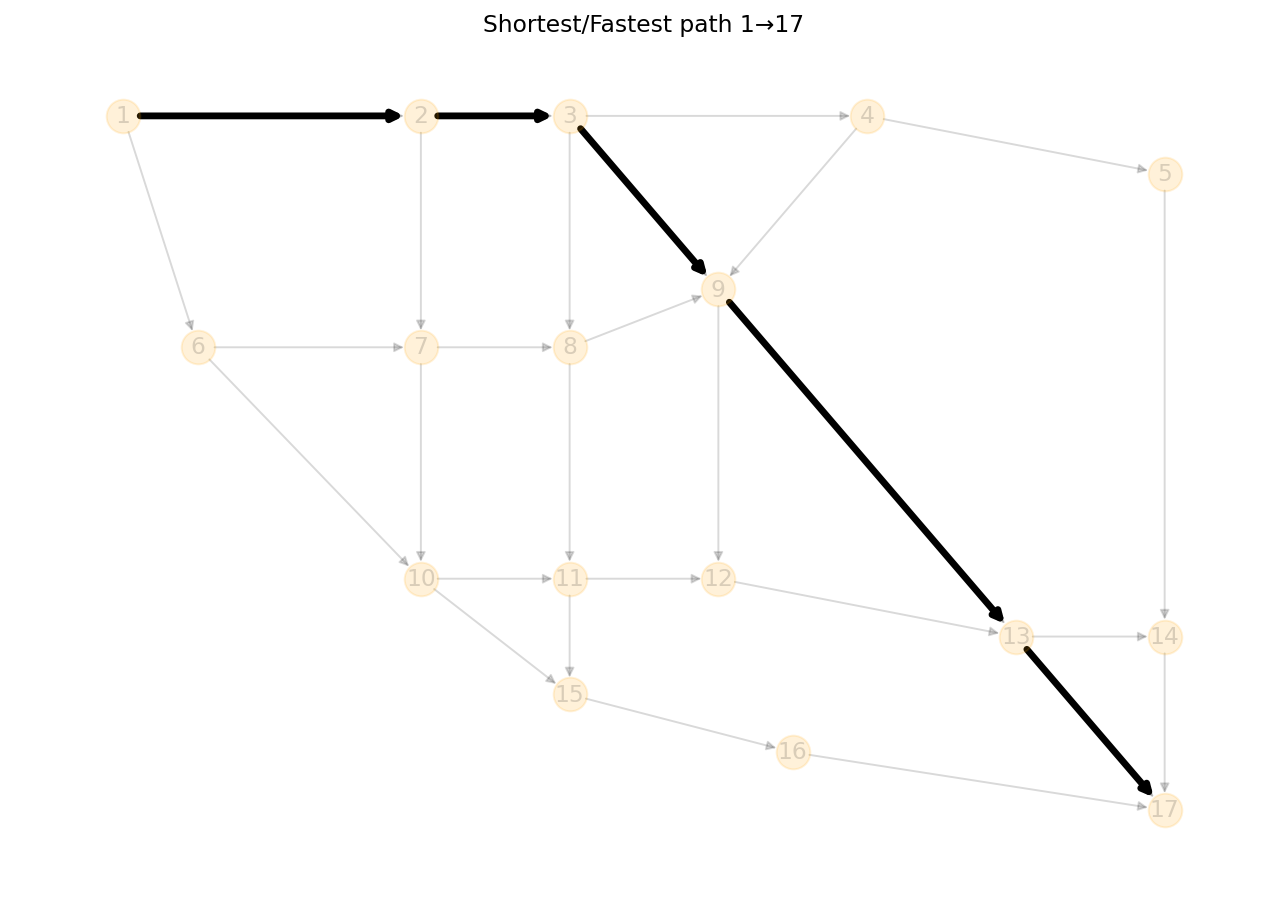

In [11]:
# compute the shortest (fastest) path from node 1 to node 17 using travel-time weights
faster = nx.shortest_path(G, 1, 17, weight='weight')
print(f"Fastest path: {faster}")

# convert the path into edge pairs so we can highlight it
pe = list(zip(faster[:-1], faster[1:]))

# plot the network and highlight the chosen path
plt.figure(dpi=140, figsize=(9, 6))
nx.draw(G, pos, with_labels=True, node_color='orange', alpha=0.15, arrows=True)

# draw the fastest-path edges with extra width so they stand out
nx.draw_networkx_edges(G, pos, edgelist=pe, width=3.5, arrows=True)

plt.title("Shortest/Fastest path 1→17")
plt.axis('off')
plt.tight_layout()
plt.show()


b

In [12]:
# compute the maximum s-t flow from node 1 to node 17
val, flow = nx.maximum_flow(G, 1, 17, capacity='capacity')

# print the total max-flow value
print("Max flow 1→17:", val)


Max flow 1→17: 22448.0


c

In [13]:
# compute ν = Bf  (net inflow at each node under the given flow F)
v = B @ F

# build a vector ν with only source/sink imbalance
nu = np.zeros_like(v)
nu[0] = v[0]       # positive supply at node 1
nu[-1] = -v[0]     # equal demand at node 17

print("v =", v)
print("nu =", nu)


v = [ 16806   8570  19448   4957   -746   4768    413     -2  -5671   1169
     -5  -7131   -380  -7412  -7810  -3430 -23544]
nu = [ 16806      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0 -16806]


d

In [14]:
import cvxpy as cp

# flow variables for all links
f = cp.Variable(len(C))

# numerator = L*C  (used in the BPR-style travel time expression)
num = L * C
# denominator part (1 - f/C), kept separate for clarity
den = 1 - f / C

# social cost objective using the given formula
objective = cp.Minimize(
    cp.sum(cp.multiply(num, cp.inv_pos(den)) - num)
)

# --- flow conservation + capacity constraints ---
constraints = [
    B @ f == nu,    # node balance constraints 
    f >= 0,         # no negative flows
    f <= C          # capacity limits
]

# solve the convex problem
prob = cp.Problem(objective, constraints)
res = prob.solve()

print("The social optimum flow vector is:\n", f.value)
print("\nThe cost of the social optimum is:", res)

# store the optimal flow for later use if needed
f_star = f.value


The social optimum flow vector is:
 [6.56934343e+03 5.81000870e+03 3.04697202e+03 3.04697044e+03
 1.02366566e+04 4.66633524e+03 3.06121109e+03 2.59598535e+03
 3.10455509e+03 7.59334729e+02 5.72744560e-03 2.76303096e+03
 1.57821332e-03 3.04697044e+03 5.57032133e+03 2.89383855e+03
 5.04094165e+03 2.36445888e+03 4.65231471e+02 2.25446280e+03
 3.35906803e+03 5.61353083e+03 2.37198823e+03 1.99673781e-03
 6.34609768e+03 5.41895867e+03 5.04094365e+03 5.04094365e+03]

The cost of the social optimum is: 26142.669749995475


e

In [15]:
import cvxpy as cp

# decision variables: flow on each link
f = cp.Variable(len(C))

# Wardrop cost uses:  - l_e * c_e * log(1 - f_e/c_e)
num = L * C              # l_e * c_e
den = 1 - f / C          # (1 - f_e/c_e)

# total Wardrop potential to minimize
objective = cp.Minimize(
    cp.sum(cp.multiply(-num, cp.log(den)))
)

# standard flow and capacity constraints
constraints = [
    B @ f == nu,   # flow conservation
    f >= 0,
    f <= C
]

# solve convex program
prob = cp.Problem(objective, constraints)
wardrop_cost = prob.solve()

print("Wardrop equilibrium f^(0):\n", f.value)
print("\nWardrop cost:", wardrop_cost)

# save for later use
f_wardrop = f.value


Wardrop equilibrium f^(0):
 [6.55752880e+03 6.30856524e+03 2.20068400e+03 2.20068399e+03
 1.02484712e+04 4.70668091e+03 2.86004234e+03 2.23275882e+03
 3.35000775e+03 2.48963554e+02 1.16567931e+01 4.09622445e+03
 1.02921940e-05 2.20068399e+03 5.54179029e+03 2.34330113e+03
 5.29409128e+03 2.09560213e+03 6.38940315e+02 2.97897553e+03
 2.98224143e+03 5.96121696e+03 2.52233127e+03 1.59560460e-05
 6.78889343e+03 4.72301527e+03 5.29409130e+03 5.29409130e+03]

Wardrop cost: 15731.952645145851


f

In [16]:
import numpy as np
import cvxpy as cp

# compute derivative of the link travel time at the social optimum f*
tau_prime_star = L / C / (1 - f_star / C)**2     # τ'_e(f*_e)
# marginal-cost tolls on each link
omega = f_star * tau_prime_star                  # ω_e

print("tolls ω =\n", omega)

# ---------- 2) New Wardrop equilibrium with tolls: τ_e(f) + ω_e ----------

# decision variable: flows under the tolled network
f = cp.Variable(C.size)

den = 1 - f / C          # 1 - f_e/c_e
num = L * C              # l_e * c_e (just a constant vector)

# potential for τ_e(f): ∫_0^f τ_e(s) ds = -l_e c_e log(1 - f_e/c_e)
int_term  = cp.multiply(-num, cp.log(den))
# add toll term ω_e f_e
toll_term = cp.multiply(omega, f)

# total potential = "Wardrop potential" + toll payments
objective = cp.Minimize(cp.sum(int_term + toll_term))

constraints = [
    B @ f == nu,              # flow conservation (same demand pattern)
    f >= 0,
    f <= (1 - 1e-6) * C       # slightly below capacity to keep log() well-defined
]

prob = cp.Problem(objective, constraints)
res = prob.solve()

f_omega = f.value

print("\nWardrop equilibrium with tolls f(ω):\n", f_omega)
print("\nWardrop+toll cost:", res)

# quick check: how close the tolled Wardrop is to the social optimum f*
print("\nmax |f(ω) - f*| =",
      float(np.max(np.abs(f_omega - f_star))))


tolls ω =
 [1.97371212e+00 1.93185260e-01 4.94321708e-02 1.00105630e-01
 1.51262298e+00 4.83581917e-01 1.12308326e-01 5.96491421e-02
 2.71746609e-01 8.28822288e-03 6.86534901e-08 6.74379905e-02
 1.81770490e-08 1.20074588e-01 4.98206045e-01 8.46540615e-02
 7.33936718e-02 1.91806007e-02 1.51427351e-03 1.31130689e-02
 6.77361885e-02 2.57080488e-01 6.69406585e-02 1.15024293e-08
 3.91851029e-01 2.69514922e-01 1.47693494e-01 5.97988353e-01]

Wardrop equilibrium with tolls f(ω):
 [6.56822664e+03 5.80995720e+03 3.04720968e+03 3.04720964e+03
 1.02377733e+04 4.66745651e+03 3.06106238e+03 2.59576939e+03
 3.10440870e+03 7.58269437e+02 1.14385913e-04 2.76274740e+03
 4.17746158e-05 3.04720964e+03 5.57031684e+03 2.89394447e+03
 5.04103594e+03 2.36466357e+03 4.65293098e+02 2.25410814e+03
 3.35923750e+03 5.61334564e+03 2.37178700e+03 6.19716244e-05
 6.34596734e+03 5.41899664e+03 5.04103600e+03 5.04103600e+03]

Wardrop+toll cost: 63020.484570516506

max |f(ω) - f*| = 1.121265194766238


g

In [17]:
lc = L * C                 # precompute l_e * c_e for all links

# decision variables: flows on each link under the new cost ψ
f = cp.Variable(len(C))

# objective: total additional travel time compared to free-flow
obj = cp.Minimize(cp.sum(
    cp.multiply(lc, cp.inv_pos(1 - f/C))   # l_e c_e / (1 - f_e/c_e)
    - lc                                   # subtract free-flow part l_e c_e
    - cp.multiply(L, f)                    # subtract l_e f_e (free-flow travel)
))

# same flow conservation and capacity constraints as before
constraints = [B @ f == nu, f >= 0, f <= (1 - 1e-6) * C]

# solve the optimization problem
prob = cp.Problem(obj, constraints)
cost_add = prob.solve()

# optimal flows for the new "extra delay" system cost
f_add = f.value
print("System optimum f* (extra delay):\n", f_add)
print("Cost_additional =", cost_add)


System optimum f* (extra delay):
 [6.58451092e+03 5.57770826e+03 3.36756474e+03 3.36755931e+03
 1.02214891e+04 4.66944309e+03 3.15651861e+03 2.71195151e+03
 2.98789184e+03 1.00680265e+03 3.72613978e-03 2.21013980e+03
 5.42574489e-03 3.36755931e+03 5.55204599e+03 3.08485435e+03
 4.98691878e+03 2.51972714e+03 4.44570826e+02 1.93420489e+03
 3.52942307e+03 5.46362796e+03 2.20221143e+03 2.10761094e-03
 6.24930837e+03 5.56977074e+03 4.98692089e+03 4.98692089e+03]
Cost_additional = 15350.354156543925


In [18]:
# link travel times and derivatives at the new system-optimal flow f_add
tau_star       = L / (1 - f_add / C)
tau_prime_star = L / C / (1 - f_add / C)**2

# tolls for the "extra delay" cost: ω*_e = -l_e + f*_e τ'_e(f*_e)
omega_star = -L + f_add * tau_prime_star

print("omega* =\n", omega_star)


omega* =
 [ 1.84409493  0.11050336 -0.07080121 -0.06644728  1.36743525  0.40688501
  0.02703781  0.0086781   0.10174903 -0.09363526 -0.10666996 -0.0593498
 -0.11232994 -0.03405669  0.36994455  0.01771026 -0.00366055 -0.03549044
 -0.03122566 -0.02462336  0.00924166  0.12343002 -0.02081019 -0.05416699
  0.27206251  0.22842245  0.02586515  0.42353099]


In [19]:
# decision variable: flows at Wardrop equilibrium under tolls omega*
f_w = cp.Variable(len(C))

den = 1 - f_w / C

# potential for the BPR travel time part: ∫_0^f τ_e(s) ds
int_term  = cp.multiply(-lc, cp.log(den))   # - l_e c_e log(1 - f_e/c_e)
# extra term coming from tolls: ω*_e f_e
toll_term = cp.multiply(omega_star, f_w)

# minimize total "Wardrop potential + toll payments"
obj_w = cp.Minimize(cp.sum(int_term + toll_term))
cons_w = [B @ f_w == nu, f_w >= 0, f_w <= (1 - 1e-6) * C]

prob_w = cp.Problem(obj_w, cons_w)
cost_w = prob_w.solve()

f_omega_star = f_w.value
print("\nWardrop with omega*:\n", f_omega_star)
print("\nWardrop+toll cost:", cost_w)

# check how close this tolled Wardrop flow is to the new system optimum f_add
print("\nmax |f(ω*) - f*| =",
      float(np.max(np.abs(f_omega_star - f_add))))



Wardrop with omega*:
 [6.58404473e+03 5.57849156e+03 3.36710426e+03 3.36710410e+03
 1.02219553e+04 4.66967101e+03 3.15623648e+03 2.71151721e+03
 2.98822719e+03 1.00555317e+03 1.03200849e-04 2.21138720e+03
 1.57163802e-04 3.36710410e+03 5.55228424e+03 3.08439095e+03
 4.98688099e+03 2.51898770e+03 4.44719374e+02 1.93467738e+03
 3.52911025e+03 5.46378763e+03 2.20260826e+03 6.85647339e-05
 6.24940656e+03 5.56971236e+03 4.98688106e+03 4.98688106e+03]

Wardrop+toll cost: 51981.20122030546

max |f(ω*) - f*| = 1.249485161031771
